<a href="https://colab.research.google.com/github/luiscosta-boop/mvp2/blob/main/mvp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#1-MVP Machine Learning & Analytics

**Nome:** Luis Henrique Magalhães Costa  
**Matrícula:** 4052026000585  
**Data:** 27/06/2026  
**Dataset:** Concrete Compressive Strength   
**Link do Repositório:** https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength  
**Tipo de problema:** Regressão  



#2-Definição do problema

##2.1-Conceitos iniciais

O concreto é um dos materiais mais utilizados na construção civil.  
No geral, o concreto é uma mistura simples de água, cimento, brita, areia e outros aditivos.  
Cada elemento dessa mistura tem sua função específica:

- **Cimento**: O ingrediente principal, responsável por unir todos os componentes

- **Água**: Fundamental para a hidratação do cimento, mas sua quantidade precisa ser cuidadosamente controlada.

- **Areia**: Contribui para a trabalhabilidade do concreto, tornando-o mais maleável

- **Brita**: Adiciona resistência mecânica à mistura, proporcionando estabilidade estrutural

- **Aditivos**: Outros aditivos podem ser adicionados à mistura no intuito de aumentar sua resistência, isso varia de acordo com o tipo de concreto buscado e os objetivos finais do projeto.

A definição da proporção (pode ser peso ou volume) dos elementos supracitados é denominada: **o traço de concreto**. A figura a seguir ilustra um traço de 1:2:3, informando que para 1 unidade de volume de cimento(referência), serão utilizadas 2 unidades de volume para areia e 3 unidades de volume para brita, além da água que também tem seu volume defino a partir da quantidade de cimento (geralmente entre 40% e 60%).  

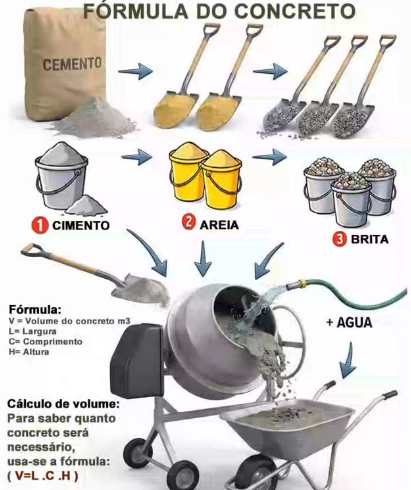


##2.2-Definição do problema

Pode-se afirmar que a resistência do concreto está diretamente relacionada com o seu traço(proporções, em peso ou em volume dos elementos utilizados na mistura).

Nos projetos de engenharia (antes da construção) , o valor da resistência que o concreto deva ter já é pre-definido. Dessa forma, podemos afirmar a relevância (durante a construção) da estimativa da resistência que o concreto terá a partir de um determinado traço (que deve ser definido e mantido o mesmo ao longo da obra).

Além da motivação ora citada, a escolha do problema também deve-se aos seguintes fatores:
 - O dataset é fruto de um trabalho científico (não são dados sintéticos)
 - As definições explicadas do concreto são de uso universal, possibilitando que o modelo possa ser utilizado e/ou expandido para outros estudos de caso em locais com clima semelhante.




##2.3 Objetivo do MVP

O objetivo deste MVP é desenvolver e analisar modelos de Aprendizado de Máquina para estimar o valor da resistência do concreto a partir dos valores (ou proporções) dos elementos utilizados na mistura, verificando a relação entre as especificades de cada atributo, modelos utilizados, hipóteses e métricas adotadas.


## 2.4 Tipo de problema

O problema deste MVP é do tipo Regressão.

O dataset é composto com 8 atributos de entrada e um de saída, conforme descrito a seguir.

**Inputs**  
- Cimento (kg/m³) - tipo real

- Escória de alto forno (kg/m³) - tipo real
  (subproduto da indústria siderúrgia - melhorando a durabilidade do concreto, resistência e sustentabilidade)

- Cinza volante (kg/m³) - tipo real
  (subproduto de usina termelétrica - aumento da resistência, porém pode
  influenciar na idade do concreto, fazendo com que precise de mais dias para atingir uma determinada resistência)

- Água (kg/m³) - tipo real

- Superplastificante (kg/m³) - tipo real
  (aditivo utilizado no concreto para diminuir a quantidade de água na mistura, aumentando a resistência da água)

- Brita (kg/m³) - tipo real

- Areia (kg/m³) - tipo real

- Idade do concreto (dias) - tipo inteiro
  (número de dias entre a concretagem e a medição da resistência)


**Output(target)**  
- Resistência do concreto (MPa) - tipo real



## 2.4 Hipóteses e critérios de sucesso


**Hipótese 1**  
Teoricamente, a relação água/cimento é o fator mais crítico. Quanto menor
for essa relação (menos água para a mesma quantidade de cimento), mais resistente será o concreto, já que haverá menos poros na massa endurecida. Para o dataset analisado a hipótese é válida? Caso positivo, é interessante incluir esse fator como um atributo? Confirmando essa inclusão, é interessante excluir os dois atributos originais (água e cimento)?

**Hipotese 2**  
Teoricamente, a proporção de agregados (areia e/ou brita) em relação ao cimento tendem a deixar o concreto menos resistente. Para o dataset analisado a hipótese é válida ? Caso positivo, é interessante incluir esse fator como um atributo? Confirmando essa inclusão, é interessante excluir os três atributos originais (água, brita e areia)?

**Hipotese 3**
Após a concretagem, a resistência do concreto aumenta com o tempo.Pela norma brasileira NBR 8116(Projeto de estruturas de concreto), alguns valores (ex: deformação) do concreto são calculados a partir de parâmetros medidos  28 dias após a concretagem (idade do concreto igual a 28). Será que essa definição da norma está associada a uma hipótese de que após 28 dias, o aumento da resistência do concreto não é significativo (assíntota horizontal)? Se positivo, seria interessante substituir os dados do atributo "idade do concreto" com o valor de 28, para todos aqueles com valores maiores que 28?


Será utilizado a métrica R2.
A restrição adotada será a interpretabilidade dos dados e resultado, considerando o fenômeno estudado.



#3-Bibliotecas

In [38]:

import os
import sys

import random
import warnings
import io
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor # algoritmo KNN
from sklearn.tree import DecisionTreeRegressor # algoritmo Árvore de Regressão
from sklearn.svm import SVR # algoritmo SVM
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,MinMaxScaler

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)




#4-Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [39]:


def metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return np.sqrt(mse),r2_score(y_true, y_pred)





# *5-Carregamento dos dados

**Descrição**  
Os dados escolhidos fazem parte de um estudo científico na área de Engenharia Civil.
O autor do trabalho fez o registro de 1030 ensaios de resistência do concreto
à compressão. Foram registrados os pesos (por m³) dos elementos da mistura, o número dias entre a concretagem e a medição (idade do concreto) e o valor da resistência do concreto medida.

O artigo pode ser verificado no link: https://doi.org/10.1016/S0008-8846(98)00165-3

**Justificativa**  
A estimativa da resistência do concreto que será encontrada nos ensaios a partir dos valores da quantidade de cada elemento da mistura é um problema clássico do curso de Engenharia Civil.
Esses a valores comumente são determinados com base na literatura (de forma simplificada) ou na experiência ("histórico de dados"), porém não há uma equação ou modelo clássico que possa servir de orientação.

Devido a quantidade e a qualidade dos dados registrados para este problema, a aplicabilidade (já que os conceitos físicos considerados é universal) e pela minha área de trabalho, escolhi o dataset apresentado.


**Nome e link da fonte dos dados**
- Nome: Concrete Compressive Strength (Resistência do concreto à compressão)
- link do respositório: https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength
- link github: https://raw.githubusercontent.com/luiscosta-boop/mvp2/refs/heads/main/input.csv


In [40]:
import pandas as pd
import io

df1 = pd.read_csv('https://raw.githubusercontent.com/luiscosta-boop/mvp2/refs/heads/main/input.csv')
df1.head()

,cimento,escoria,cinza_volante,agua,superplastificante,brita,areia,idade,resistencia
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


# 6-Resumo do dataset

- O dataset apresenta 9 colunas e 1030 linhas
- Todas as colunas são formadas por números reais, com excessão da coluna 8 que é do tipo inteiro.
- Conforme citado pelo autor do trabalho científico não há dados ausentes no dataset
- Foram encontrado 25 dados duplicados (foram removidos neste tópico)
- Todas colunas serão considerados no modelo, pois exercem influência nos valores do target.
- O target está localizado na coluna 9 e representa a reposta do modelo (resistência do concreto a compressão)


**Dicionário de dados**

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| 1 | numérica (float) |Quantidade de cimento (km/m³) | sim | * |
| 2 | numérica (float) |Escória (km/m³) | sim | |
| 3 | numérica (float) |Cinza Volante (km/m³) | sim | |
| 4 | numérica (float) |Água (km/m³) | sim | * |
| 5 | numérica (float) |Superplastificante (km/m³) | sim |  |
| 6 | numérica (float) |Brita (km/m³) | sim | * |
| 7 | numérica (float) |Areia(km/m³) | sim | * |
| 8 | numérica (integer) |Idade do concreto (dias) | sim |  |
| 9 | numérica (float) |Resistência do concreto (MPa) - TARGET | sim |  |


OBS: Os atributos marcados com "*" poderão ser alterados, no fim do tópico de análise exploratória de dados.
- Inclusão de uma coluna Fator Água/Cimento "=Água/Cimento" e exclusão das duas colunas (água e cimento)
- Inclusão de uma coluna Proporção de agregados "=Cimento/(Brita+Areia) e exclusão das três colunas (cimento,brita e areia).



---------------------------

Os códigos são apresentados a seguir.

In [41]:
# Dimensão e tipo de dados do dataset
print("Dimensões:", df1.shape)
print("\nTipos de dados:")
display(df1.dtypes.to_frame("tipo"))

Dimensões: (1030, 9)

Tipos de dados:


,tipo
cimento,float64
escoria,float64
cinza_volante,float64
agua,float64
superplastificante,float64
brita,float64
areia,float64
idade,int64
resistencia,float64


In [42]:
# Verificação de dados ausentes

print("\nValores ausentes por coluna:")
display(df1.isna().sum().to_frame("ausentes"))



Valores ausentes por coluna:


,ausentes
cimento,0
escoria,0
cinza_volante,0
agua,0
superplastificante,0
brita,0
areia,0
idade,0
resistencia,0


In [43]:
#Verificação e remoção de dados duplicados
print("--------------------------------------")
print("Dados duplicados")
print("\n Dados duplicados:", df1.duplicated().sum())
df2 = df1.drop_duplicates()
print("\n------------após a remoção-----------------")
print("\n Dados duplicados:", df2.duplicated().sum())

--------------------------------------
Dados duplicados

 Dados duplicados: 25

------------após a remoção-----------------

 Dados duplicados: 0


# 7-Análise exploratória dos dados



## 7.1-Alterações iniciais

Conforme explicado nos tópicos 2.4 e 6, irei incluir duas colunas, conforme explicado a seguir:

- 1a coluna a ser adicionada: será criada a partir da divisão entre as colunas "cimento" e "agua, representando o fator a/c (água/cimento) que exerce grande influência no target (resistência do concreto)
- 2a coluna a ser adicionada: será criada a partir da divisão entra a soma das quantidades de brita e areia dividida pela quantidade de cimento. (brita+areia)/cimento.



In [44]:

# inclusão proporção de agregados
df2.insert(0, 'prop_agregados', (df2['areia']+df2['brita'])/df2['cimento'])
# inclusão fator água/cimento
df2.insert(0, 'fator_ac', 100*df2['agua']/df2['cimento'])
df2.describe()

,fator_ac,prop_agregados,cimento,escoria,cinza_volante,agua,superplastificante,brita,areia,idade,resistencia
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,75.622046,7.264605,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,31.352436,2.885819,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,26.689253,3.097760,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,54.746462,4.965924,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,68.953069,6.640000,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,93.724097,9.566069,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,188.235294,17.931373,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


Pela norma brasileira de projeto de projetos de estruturas de concreto (NBR 6118) o valor máximo do fator_ac (fator água/cimento) deva ser de 65%. (vale lembrar que quanto menor, mais resistente será o concreto).  

Pela tabela acima podemos perceber que:


*   A média dos desses valores está em 75.6%
*   Metade dos valores dos dados estão em até 68.95%
*   O valor máximo esté em 188%.


Esse valor ficar acima de 100 (ter mais água do que cimento na mistura) é algo inviável e que não faz sentido. Dessa forma, resolvi remover todos as linhas com esse valor superior a 90%.

No que se refere a idade do concreto, a norma define esse valor para as medições em 28 dias. No dataset, esse valor máximo é de 365 (1 ano). Por entender que a influência da idade na resistência do concreto vai diminuindo com o tempo, adotei a estratégia de substituir no dataset um valor máximo de 4 meses, ou seja, valores maiores que 120, passarão a ser 120.

In [45]:
df2 = df2[df2['fator_ac'] <= 90]
#df2 = df2[df2['idade'] <= 120]
df2.loc[df2['idade'] > 120, 'idade'] = 120

df2.describe()

,fator_ac,prop_agregados,cimento,escoria,cinza_volante,agua,superplastificante,brita,areia,idade,resistencia
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,59.838334,5.907133,321.682240,48.910792,47.162432,179.874454,6.296311,978.747951,773.529235,38.524590,38.440068
std,15.881514,1.794310,88.731791,74.446150,57.424900,22.114931,6.199762,79.953096,81.504026,35.880951,16.343282
min,26.689253,3.097760,168.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,6.270000
25%,48.000000,4.589474,251.400000,0.000000,0.000000,162.000000,0.000000,932.000000,734.000000,7.000000,25.442500
50%,58.112094,5.556519,310.000000,0.000000,0.000000,185.000000,6.300000,968.000000,779.850000,28.000000,38.010000
75%,73.554642,7.224400,380.000000,98.100000,100.400000,192.000000,10.300000,1046.900000,822.650000,56.000000,49.777500
max,90.000000,10.945238,540.000000,359.400000,174.700000,228.000000,32.200000,1134.300000,992.600000,120.000000,82.600000


##7.2-Construção dos gráficos

Neste tópico serão apresentados gráficos do tipo:

- Distribuição (histograma)
- Dispersão
- Boxplot
- Correlações entre as variáveis e o target (gráfico em barras)


### 7.2.1- Histogramas

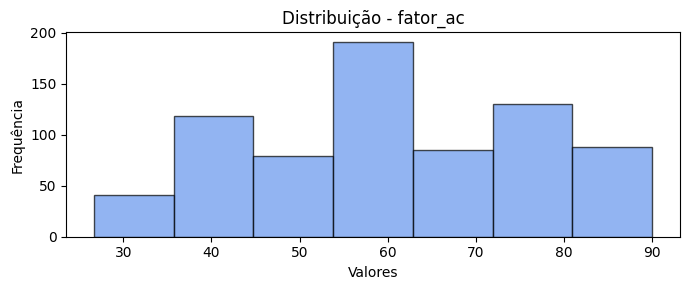

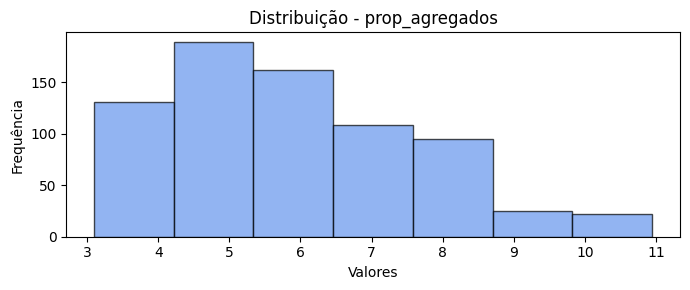

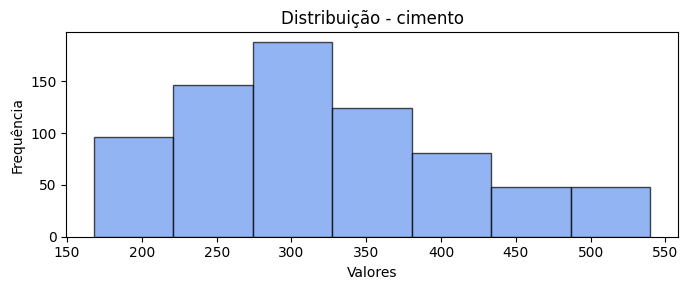

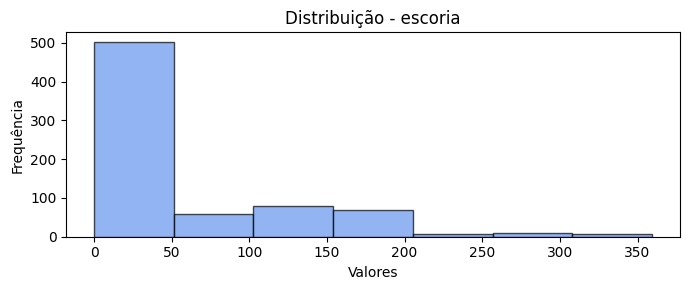

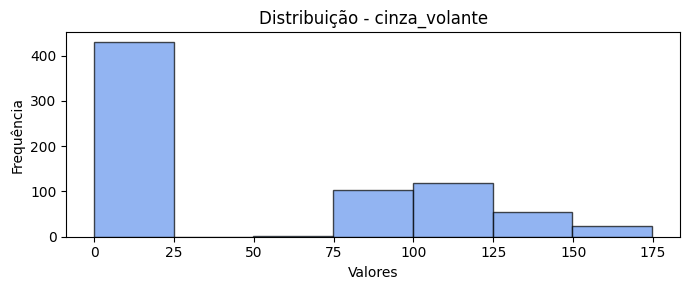

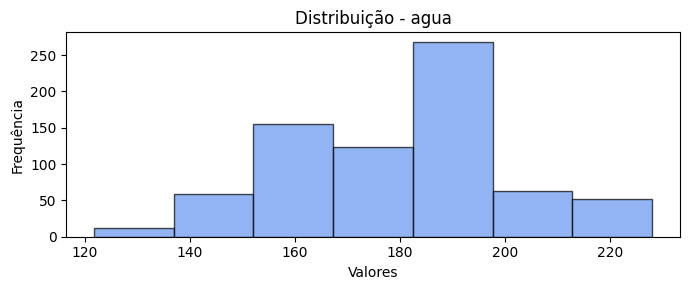

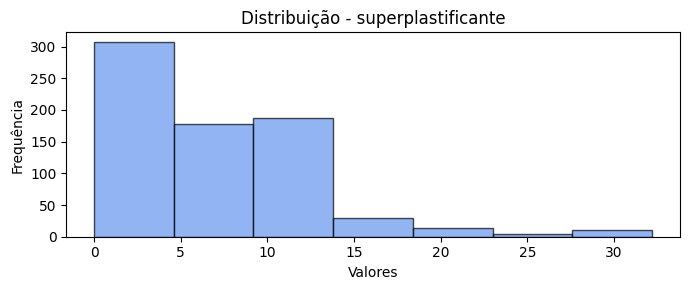

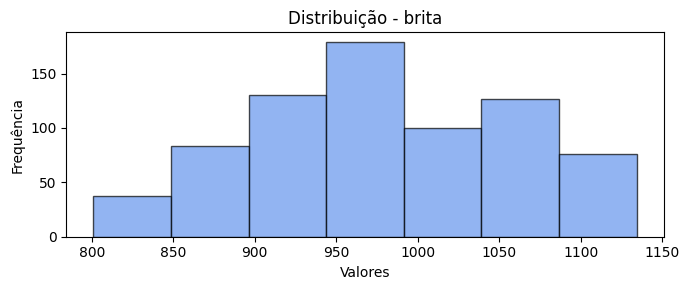

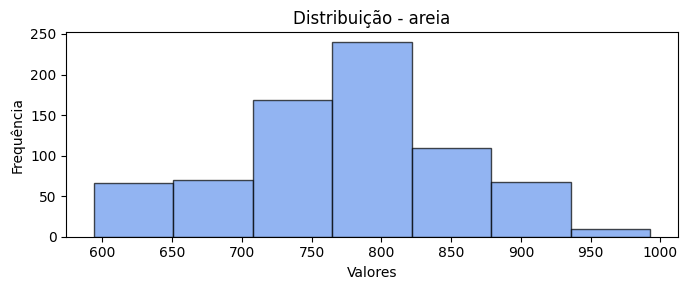

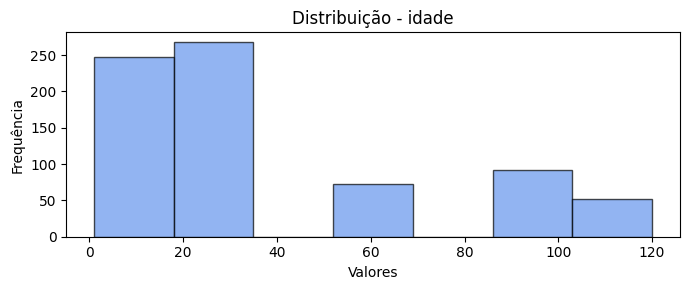

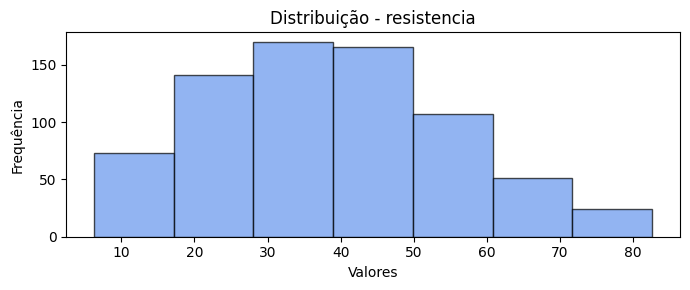

In [46]:

for nome_col in df2.columns:
  plt.figure(figsize=(7, 3))
  plt.hist(df2[nome_col], bins=7, color='cornflowerblue', edgecolor='black', alpha=0.7)
  # Adicionando títulos e rótulos para melhor visualização
  plt.title('Distribuição - '+nome_col)
  plt.xlabel('Valores')
  plt.ylabel('Frequência')
  plt.tight_layout()
  plt.show()




###7.2.2-Boxplot

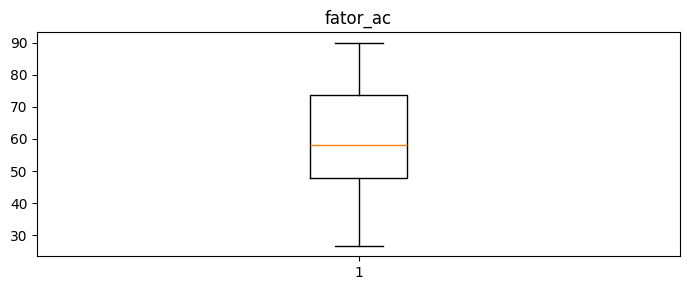

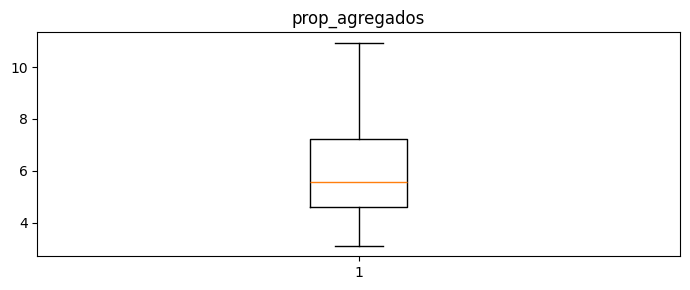

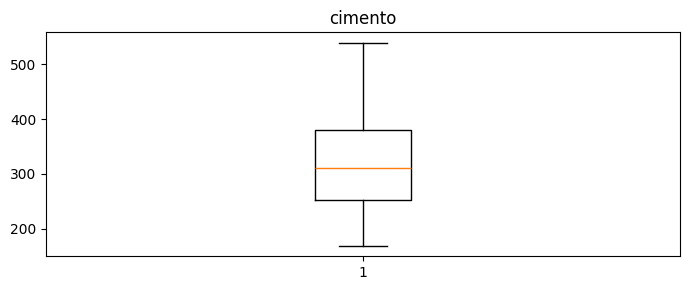

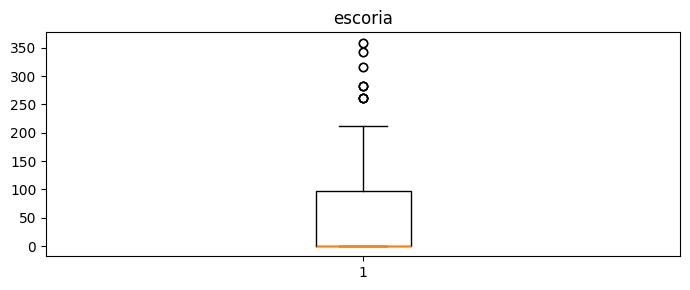

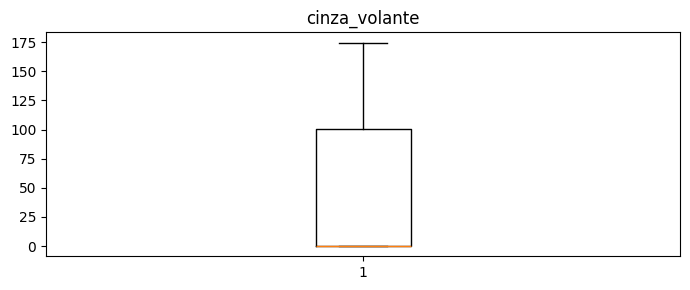

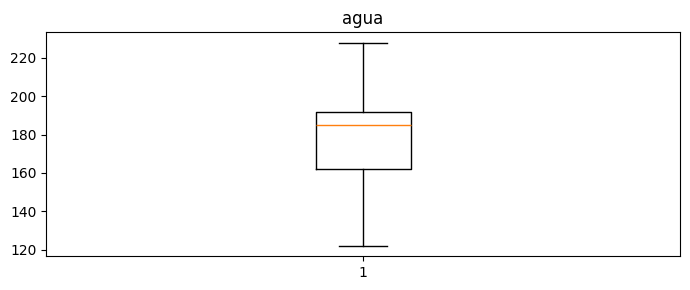

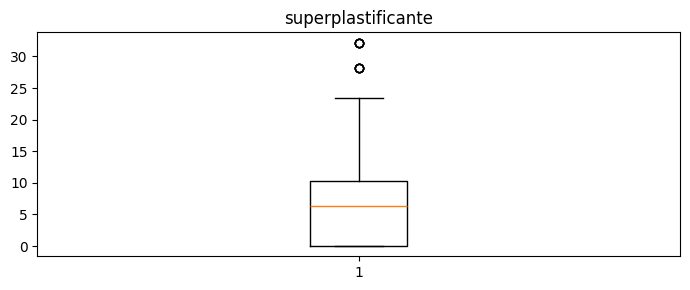

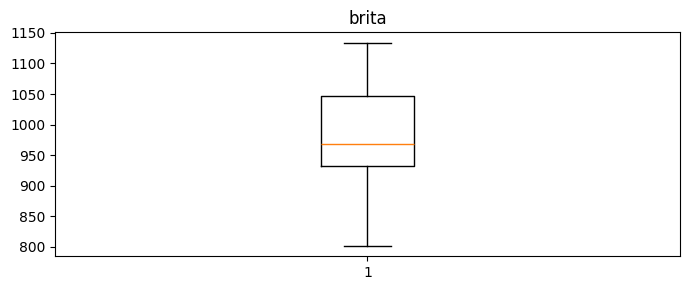

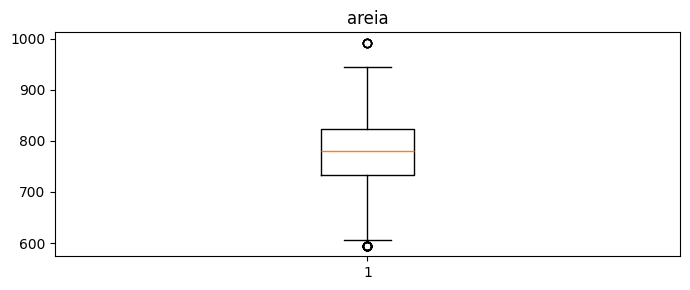

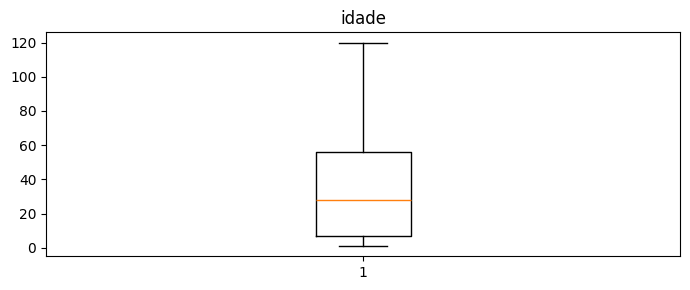

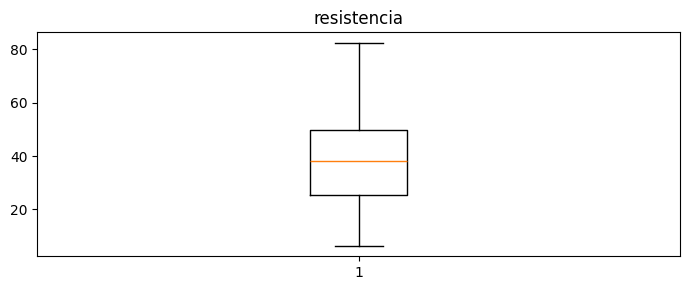

In [47]:
for nome_col in df2.columns:
  plt.figure(figsize=(7, 3))
  plt.boxplot(df2[nome_col])
  plt.title(nome_col)
  plt.tight_layout()
  plt.show()

In [48]:
#Remoção dos outliers (escória e superplastificante)
df2 = df2[df2['escoria'] <= 250]
df2 = df2[df2['superplastificante'] <= 250]

###7.2.3-Dispersão: inputs-taget

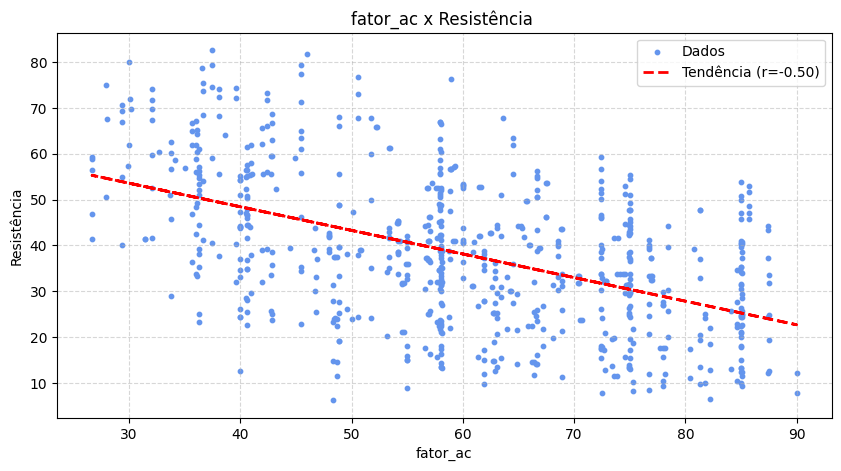

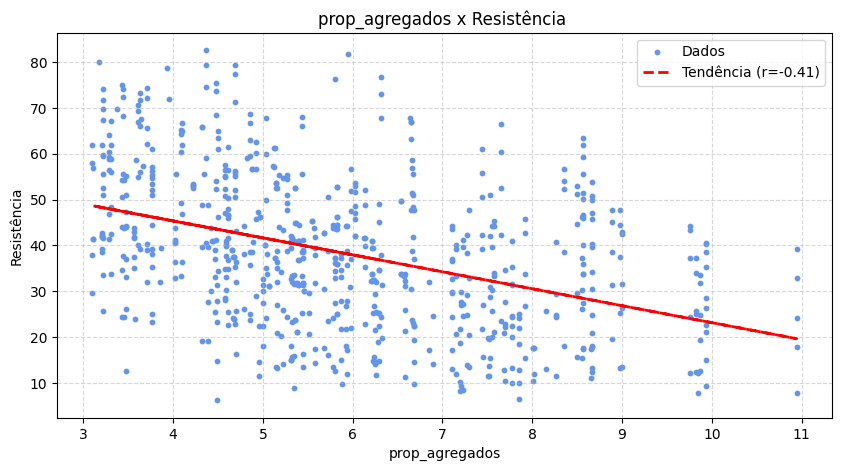

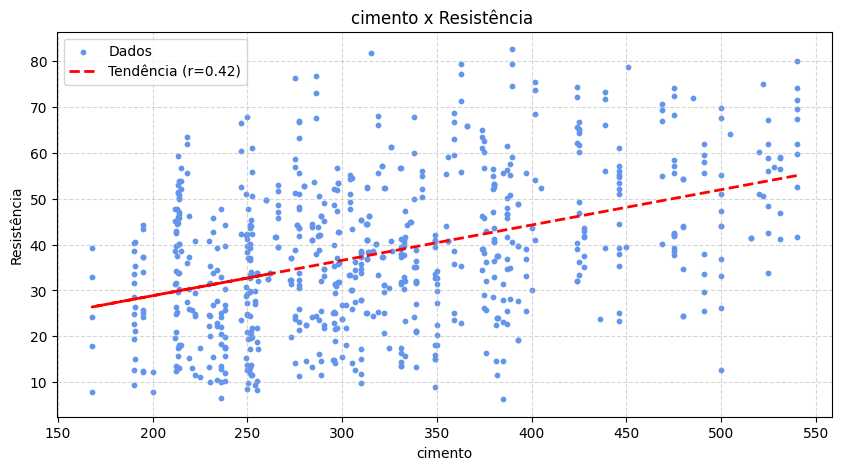

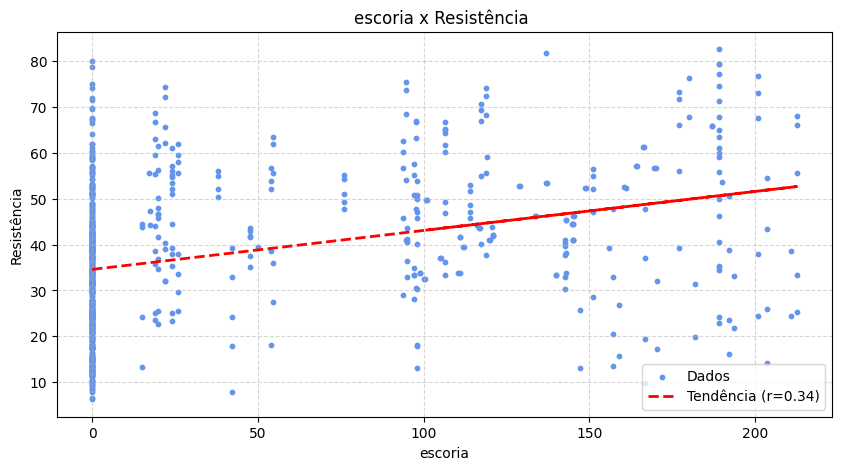

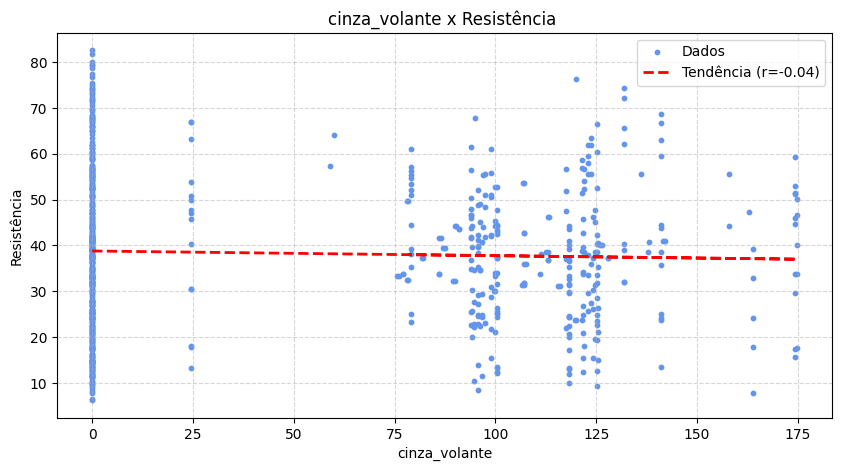

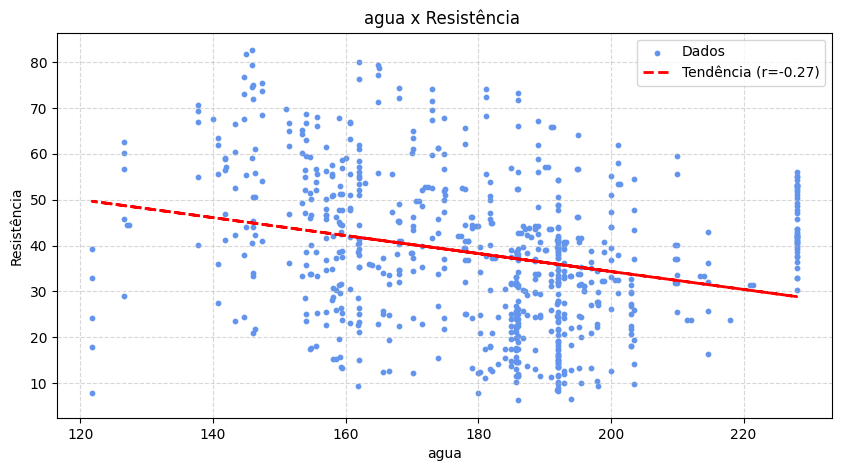

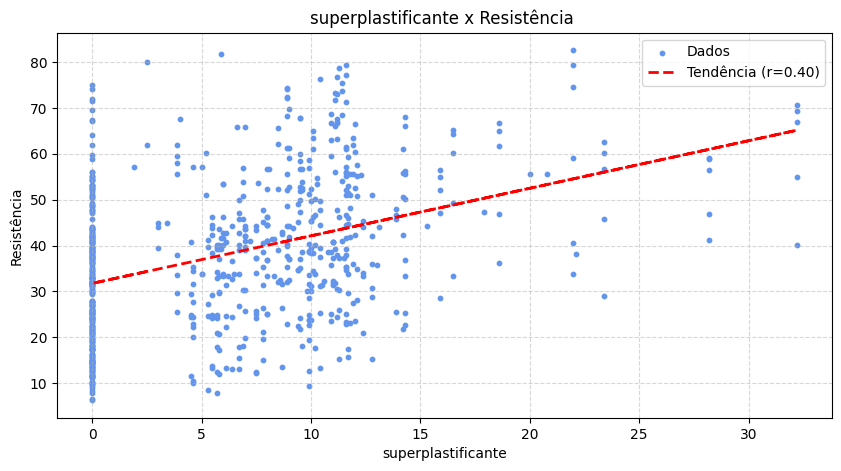

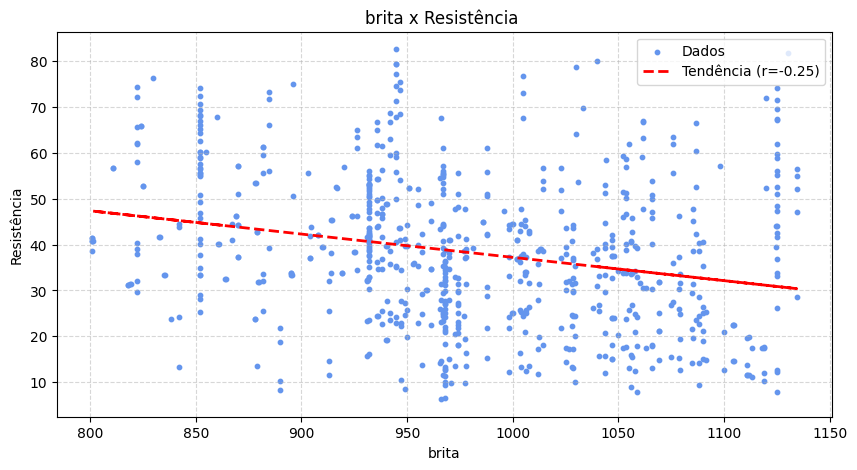

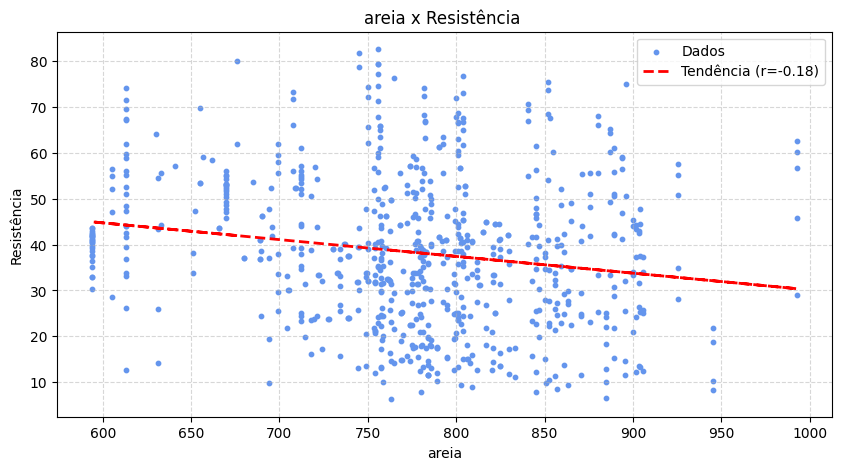

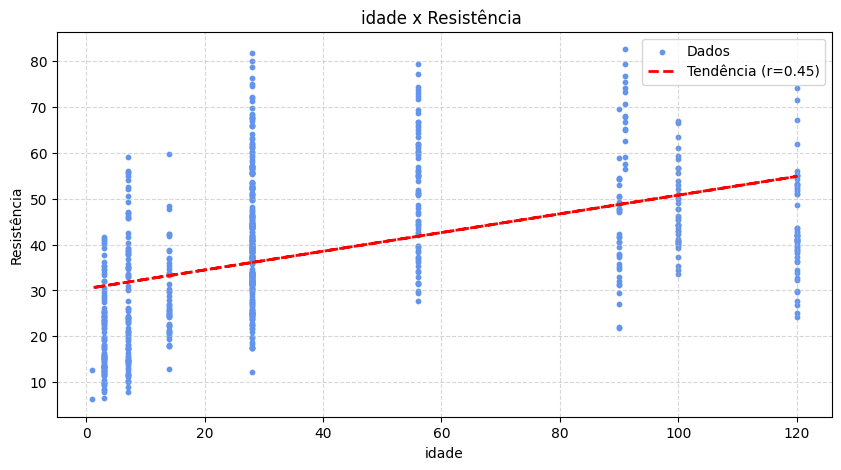

In [49]:
for nome_col in df2.columns:
  if nome_col != 'resistencia':
    x = df2[nome_col].to_numpy()
    y = df2['resistencia'].to_numpy()
    correlacao = np.corrcoef(x, y)[0, 1]
    plt.figure(figsize=(10, 5))
    plt.scatter(x,y,s=10,c='cornflowerblue',label='Dados')
    a,b = np.polyfit(x, y, 1)
    plt.plot(x, a*x + b, color='red', linestyle='--', linewidth=2, label=f'Tendência (r={correlacao:.2f})')

    plt.title(nome_col+' x Resistência ')
    plt.xlabel(nome_col)
    plt.ylabel("Resistência")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


###7.2.4- Correlações (target)

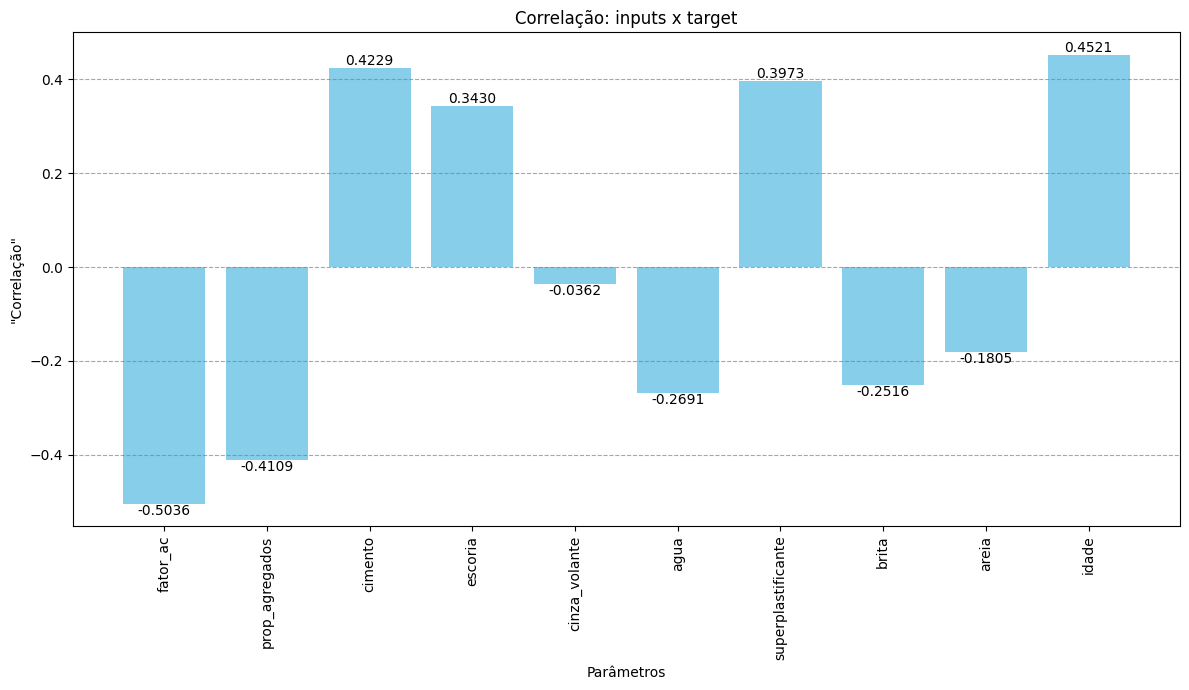

In [50]:
matriz_correlacao = df2.corr()
inputs = matriz_correlacao[['resistencia']].drop('resistencia')
#inputs.head()
#sns.heatmap(inputs,annot=True,cmap='RdBu',vmin=-1,vmax=1)
#print(inputs)

r = inputs.iloc[:, 0].to_numpy()
nomes_input = list(df2.columns)
nomes_input.pop()
fig,ax = plt.subplots(figsize=(12,7))
ax.bar(nomes_input, r, color='skyblue')
for c in ax.containers:
    ax.bar_label(c, fmt='{:,.4f}')
# Adicionar títulos e rótulos
plt.title('Correlação: inputs x target')
plt.xlabel('Parâmetros')
plt.ylabel('"Correlação"')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', color='gray', alpha=0.7)
# Exibir
plt.show()

##7.3-Considerações Finais

As principais conclusões obtidas após a AED estão organizadas na tabela a seguir. (obs: não há dados ausente no dataset)

|fator_ac| (fator água/cimento)|
|---|---|
|Distribuição|os valores mais repetidos estão em torno da média, porém não chega ser simétrica|
|Relação com o Target|foi a variável que teve a maior correlação(-0.5)|
|Outliers|não|
|Será utilizada no modelo?|sim|
|Comentário 1|essa variável foi incluída. Valores superiores à 90 foram removidos (item 7.1).|
|Comentário 2|o valor da correlação faz sentido pois quanto menor o favor água/cimento, maior será a resistência|    


|prop_agregados| (proporção de agregados)|
|---|---|
|Distribuição|assimétrica positiva|
|Relação com o Target|correlação=-0.41)|
|Outliers|não|
|Será utilizada no modelo?|sim|
|Comentário|Essa variável foi incluída. (item 7.1)|

|cimento| |
|---|---|
|Distribuição|parcialmente simétrica|
|Relação com o Target|correlação=0.42)|
|Outliers|não|
|Será utilizada no modelo?|não|
|Comentário|Essa variável foi removida, porém seu valor faz parte das duas variáveis anteriores. (item 7.1)|

|escoria|(aditivo) |
|---|---|
|Distribuição|assimétrica positiva -  isto ocorre devido a grande quantidade de zeros|
|Relação com o Target|correlação=-0.27)|
|Outliers|sim-valores acima de 250 foram removidos|
|Será utilizada no modelo?|não|
|Comentário|-|

|cinza_volante|(aditivo)|
|---|---|
|Distribuição|irregular|
|Relação com o Target|correlação=-0.03)|
|Outliers|não|
|Será utilizada no modelo?|não|
|Comentário|-|

|agua||
|---|---|
|Distribuição|assimétrica negativa|
|Relação com o Target|correlação=-0.27)|
|Outliers|não|
|Será utilizada no modelo?|não|
|Comentário|Seu valor faz parte da 1a variáveil(fator_ac). (item 7.1)|

|superplastificante|(aditivo) |
|---|---|
|Distribuição|assimétrica positiva -  isto ocorre devido a grande quantidade de zeros|
|Relação com o Target|correlação=0.39)|
|Outliers|sim-valores acima de 25 foram removidos do dataset|
|Será utilizada no modelo?|sim|
|Comentários|-|

|brita|(agregado)|
|---|---|
|Distribuição|parcialmente simétrica|
|Relação com o Target|correlação=-0.25)|
|Outliers|não|
|Será utilizada no modelo?|não|
|Comentário|Seu valor faz parte da variável prop_agregados|

|areia|(agregado)|
|---|---|
|Distribuição|simétrica|
|Relação com o Target|correlação=-0.18)|
|Outliers|não|
|Será utilizada no modelo?|não|
|Comentário|Seu valor faz parte da variável prop_agregados|

|idade||
|---|---|
|Distribuição|irregular|
|Relação com o Target|correlação=0.45)|
|Outliers|não|
|Será utilizada no modelo?|sim|
|Comentário|Para valores maiores que 120, foi adotado 120(item 7.1)|

|resistencia| (TARGET)|
|---|---|
|Distribuição|simétrica|
|Relação com o Target|-|
|Outliers|não|
|Será utilizada no modelo?|sim|
|Comentário|o target está balanceado|

#8-Preparação e divisão dos dados
OBS: A remoção de outliers e de atributos foi realizada no tópico 7.3.  

A validação cruzada foi utilizada para que todos os dados sejam considerados no treino e teste. Também devido a pequena quantidade de dados (em torno de 700)  

Não utilizei a técnica Feature Selection, pois removi algumas colunas manualmente na etapa de AED. Também criei duas , com "transformações" daquelas que foram removidas.


In [51]:
#exclusão dos atributos
df2 = df2.drop(columns=['cimento'])
df2 = df2.drop(columns=['cinza_volante'])
df2 = df2.drop(columns=['areia'])
df2 = df2.drop(columns=['brita'])
df2 = df2.drop(columns=['agua'])
# separação features-target
features = list(df2.columns)
target=features.pop()
X = df2[features].copy()
Y = df2[target].copy()
#divisão dos dados
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size=0.2, random_state=SEED)
kfold = KFold(n_splits=7, shuffle=True, random_state=SEED)

#9-Baseline
Para servir de referência para os modelos candidatos, será utilizado um modelo base de regressão linear multipla com os dados originais

In [52]:
modelo_baseline = LinearRegression()
modelo_baseline.fit(X_treino, Y_treino)
Y_previsto = modelo_baseline.predict(X_teste)

# 6. Avalie o Modelo
r2 = r2_score(Y_teste, Y_previsto)
rmse = mean_squared_error(Y_teste, Y_previsto)

print(f"Coeficientes: {modelo_baseline.coef_}")
print(f"Constante: {modelo_baseline.intercept_:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

Coeficientes: [-0.5542409   0.89434251  0.06806325  0.64425227  0.2389671 ]
Constante: 49.81
R²: 0.62
RMSE: 88.82


#10-Modelos candidatos
Os modelos candidados considerados são:

- KNN
- Árvore de Decisão
- Floresta Aleatória
- Gradient Boosting Regressor (Método Ensemble-Boosting)

Considerei esse modelos por acreditar que são aplicáveis em situações em que a relação entre as variáveis e o target é não-linear.

O formado dos dados considerados foram os originais, padronizados e normalizados. Para tanto, foi utilizar pipelines para evitar vazamento de dados.



KNN-orig: 0.773200 - 0.033393
DTR-orig: 0.817804 - 0.026271
RFR-orig: 0.880346 - 0.018916
GBR-orig: 0.890137 - 0.013469
KNN-pad: 0.776219 - 0.039696
DTR-pad: 0.817283 - 0.030853
RFR-pad: 0.880475 - 0.018839
GBR-pad: 0.890137 - 0.013469
KNN-norm: 0.785144 - 0.034433
DTR-norm: 0.817469 - 0.034678
RFR-norm: 0.880508 - 0.018979
GBR-norm: 0.890126 - 0.013470


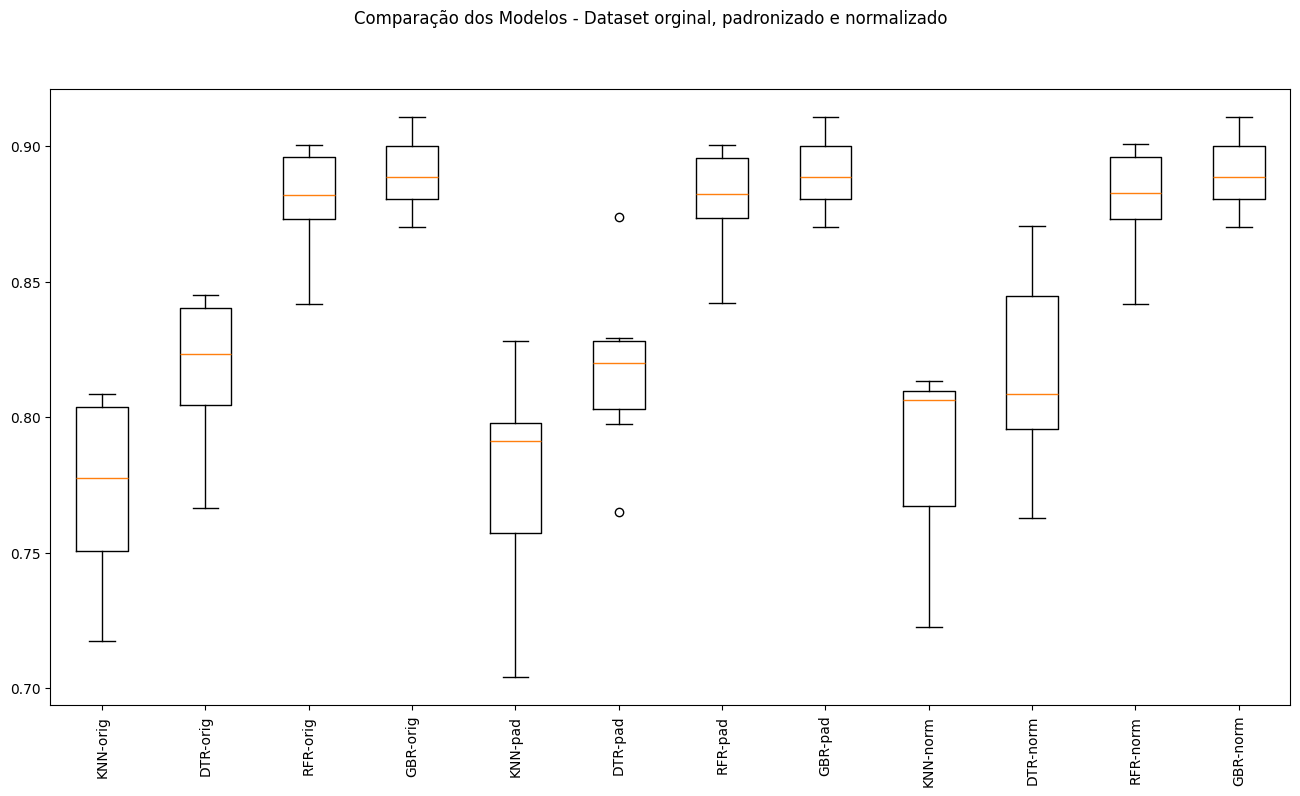

In [53]:
pipelines=[]
models = []
results = []
names = []
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())
# Montando os modelos em uma lista



knn=('KNN',KNeighborsRegressor())
dtr=('DTR',DecisionTreeRegressor())
rfr=('RFR',RandomForestRegressor(n_estimators=100, random_state=SEED))
gbr=('GBR',GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=SEED))

pipelines.append(('KNN-orig',Pipeline([knn])))
pipelines.append(('DTR-orig',Pipeline([dtr])))
pipelines.append(('RFR-orig',Pipeline([rfr])))
pipelines.append(('GBR-orig',Pipeline([gbr])))
pipelines.append(('KNN-pad',Pipeline([standard_scaler,knn])))
pipelines.append(('DTR-pad',Pipeline([standard_scaler,dtr])))
pipelines.append(('RFR-pad',Pipeline([standard_scaler,rfr])))
pipelines.append(('GBR-pad',Pipeline([standard_scaler,gbr])))
pipelines.append(('KNN-norm',Pipeline([min_max_scaler,knn])))
pipelines.append(('DTR-norm',Pipeline([min_max_scaler,dtr])))
pipelines.append(('RFR-norm',Pipeline([min_max_scaler,rfr])))
pipelines.append(('GBR-norm',Pipeline([min_max_scaler,gbr])))


for name, model in pipelines:
    resultados = cross_val_score(model, X_treino, Y_treino, cv=kfold, scoring='r2')
    results.append(resultados)
    names.append(name)
    print("%s: %f - %f" % (name, resultados.mean(), resultados.std()))


fig = plt.figure(figsize=(16,8))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot()
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

**Considerações**  



*   Entendo que os modelos candidatos considerados são mais apropiados para relações numéricas não lineares.
*   Foram verificados o formato dos dados originais, normalizados e padronizados.
*    A métrica utilizada foi o R².
*   Todos os modelos candidatos ficaram melhores que o modelo base.


#11-Validação e otimização dos parâmetros

Considerando os resultados no item anterior, o modelo mais indicado foi o GradientBoostingRegressor, considerando os dados originais do dataset.

Na otimização dos parâmeatros serão considerados:


*   O número de árvores (n_estimators)
*   A taxa de aprendizado (learning_rate)
*   Profundidade máxima da árvore (max_depth)
*   O número mínimo de dados para dividir um nó (min_samples_split)



In [54]:
#validação com o modelo escolhido antes da otimização
gbr=GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=SEED)
gbr.fit(X_treino, Y_treino)
Y_pred = gbr.predict(X_teste)
# 7. Avaliar o desempenho do modelo
rmse,r2=metricas(Y_pred,Y_teste)
print('RMSE: ',rmse)
print('r2: ',r2)

RMSE:  5.243562581813811
r2:  0.8615476447701707


In [55]:
# Otimização dos parâmetros
gbr2 = GradientBoostingRegressor(random_state=SEED)
#configurando a variação dos parâmetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01,0.05,0.1, 0.2],
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5,7]
}
#configurando o grid search (duração em torno de 3 min)
grid_search = GridSearchCV(
    estimator=gbr2,
    param_grid=param_grid,
    scoring='r2',
    cv=7,
    n_jobs=-1
)

grid_search.fit(X_treino, Y_treino)

# Exibindo os melhores parâmetros
print("Parametros:", grid_search.best_params_)
print("R2:", grid_search.best_score_)

Parametros: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
R2: 0.9132717278179475


In [56]:
# Validando o modelo com os parâmetros otimizados

gbr_opt=GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,min_samples_split=2, random_state=SEED)
resultado=gbr_opt.fit(X_treino, Y_treino)
Y_pred = gbr_opt.predict(X_teste)
Y_pred_treino=gbr_opt.predict(X_treino)
# 7. Avaliar o desempenho do modelo
rmse,r2=metricas(Y_pred,Y_teste)
print('RMSE:(validação) ',rmse)
print('r2:(validação) ',r2)


RMSE:(validação)  5.403231017750462
r2:(validação)  0.871173559486289


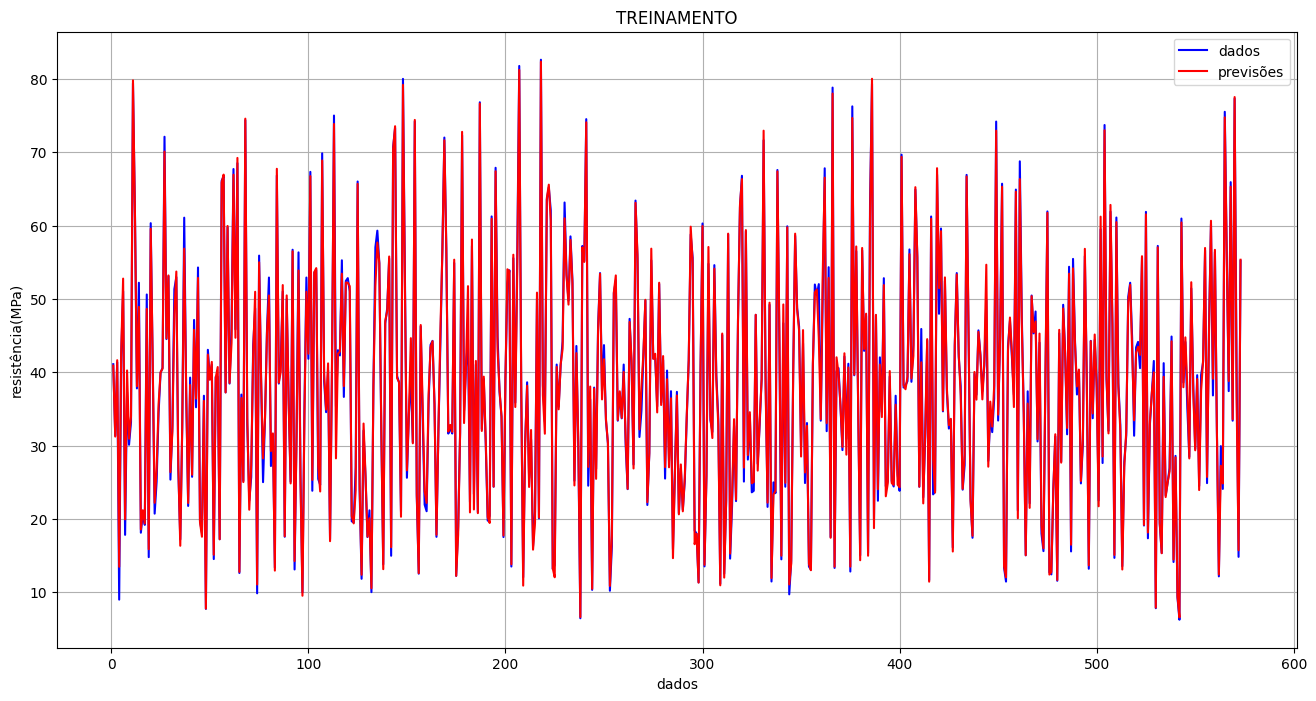

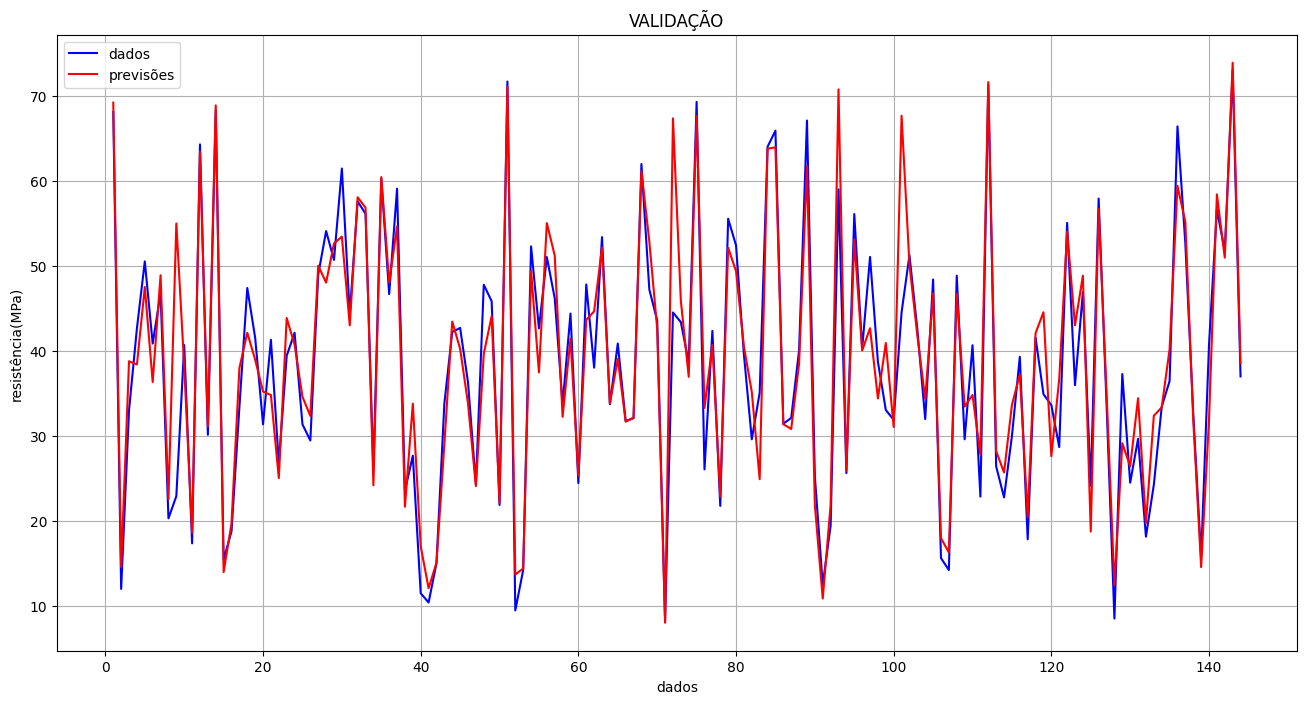

In [57]:
#Graficos


idados=list(range(1,len(Y_treino)+1))
# Cria as duas séries de linhas
fig = plt.figure(figsize=(16,8))
plt.plot(idados, Y_treino, label='dados', color='blue')
plt.plot(idados, Y_pred_treino, label='previsões', color='red')


# Adiciona títulos, rótulos e legenda para melhor leitura

plt.title('TREINAMENTO')
plt.xlabel('dados')
plt.ylabel('resistência(MPa)')
plt.legend()
plt.grid(True)


idados=list(range(1,len(Y_teste)+1))
fig = plt.figure(figsize=(16,8))
plt.plot(idados, Y_teste, label='dados', color='blue')
plt.plot(idados, Y_pred, label='previsões', color='red')


# Adiciona títulos, rótulos e legenda para melhor leitura

plt.title('VALIDAÇÃO')
plt.xlabel('dados')
plt.ylabel('resistência(MPa)')
plt.legend()
plt.grid(True)

# 12-Conclusões

- De início, na etapa de análise de exploração de dados foram realizadas algumas modificações "manual" no dataset (tem 7.1) (por isto não foi utilizado feature selection)
- Com essas alterações (justificadas no item 7.1) podemos organizar e separar os dados, considerando a validação cruzada
- O modelo definido como baseline, por conter um método analítico para resolução (método dos mínimos quadrados) utilizado para termos como referência foi a regressão linear múltipla, tivemos um R2 de 0.65.
- Utilizamos 4 modelos candidatos e o melhor (métrica F2) foi o Gradient Boosting Regressor. O modelo apresentou R2 para treino de 0.88 e teste 0.84. Após a otimização dos parâmetros tivemos esses valores aumentados para 0.91 e 0.88, respectivamente.
- Pelos valores de R2 nos dados de teste, podemos confirmar que não houve overfitting.

Considerando a ausência de overfitting e vazamento de dados (uso de pipeline) e o valor da métrica R2 ( para treino e teste) podemos confirmar a eficiência da escolha do modelo.

De uma forma geral, os problemas de engenharia que podem ser resolvidos com técnicas de ciência de dados, são do tipo regressão (número contínuos). Como aprendizado, percebi como temos vários modelos para testar, além da importância do uso da validação cruzada e otimização dos parâmetros (por meio de métodos simples).

Como trabalho futuro, penso em desenvolver uma aplicação web em que diferentes pesquisadores/professores/alunos da área possam cadastrar seus dados (mistura do concreto x resistência), possibilitando o uso modelos de ML mais robustos  que possam fazer previsões da resistência do concreto com eficiência.  

